In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                              recall_score, confusion_matrix,
                              classification_report)
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Load final 5-feature dataset
df = pd.read_csv('data/processed/nepal_model_features.csv',
                  index_col=0, parse_dates=True)

X = df.drop(columns=['distress'])
y = df['distress']

print(f"✅ Loaded: {df.shape}")
print(f"   Features: {list(X.columns)}")
print(f"   Rows:     {len(X)}")
print(f"   Distress: {y.sum()} years ({y.mean():.1%})")

✅ Loaded: (30, 6)
   Features: ['unemployment_roll3_mean', 'gdp_growth_roll3_std', 'consumption_growth_roll3_mean', 'forex_rapid_decline', 'remittances_pct_gdp_lag1']
   Rows:     30
   Distress: 7 years (23.3%)


In [2]:
# ================================================
# LOOCV EVALUATION FUNCTION
# ================================================
# This function works for ANY model we pass in.
# We write it once and reuse for all 4 models.
# ================================================

def evaluate_model(model, X, y, model_name):
    """
    Evaluate a model using Leave-One-Out Cross Validation.
    Every year gets a turn as the test case.
    Scaling is done INSIDE the loop to prevent leakage.
    """
    loo = LeaveOneOut()
    predictions = []
    probabilities = []
    actuals = []
    years = []

    for train_idx, test_idx in loo.split(X):
        # Split
        X_train = X.iloc[train_idx]
        X_test  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        # Scale INSIDE loop — critical to prevent leakage
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        # Train and predict
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)[0]
        
        # Get probability if model supports it
        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(X_test_scaled)[0][1]
        else:
            prob = float(pred)

        predictions.append(pred)
        probabilities.append(prob)
        actuals.append(y_test.values[0])
        years.append(X.index[test_idx[0]].year)

    # Calculate metrics
    f1       = f1_score(actuals, predictions, zero_division=0)
    bal_acc  = balanced_accuracy_score(actuals, predictions)
    recall   = recall_score(actuals, predictions, zero_division=0)
    cm       = confusion_matrix(actuals, predictions)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  F1 Score:          {f1:.3f}")
    print(f"  Balanced Accuracy: {bal_acc:.3f}")
    print(f"  Distress Recall:   {recall:.3f}")
    print(f"\n  Confusion Matrix:")
    print(f"              Predicted")
    print(f"              Normal  Distress")
    print(f"  Actual Normal    {cm[0][0]:>4}    {cm[0][1]:>4}")
    print(f"  Actual Distress  {cm[1][0]:>4}    {cm[1][1]:>4}")
    print(f"\n  Misclassified years:")
    for y_true, y_pred, yr in zip(actuals, predictions, years):
        if y_true != y_pred:
            kind = "FALSE ALARM" if y_pred==1 else "MISSED"
            print(f"    {yr}: actual={y_true}, predicted={y_pred}  ← {kind}")

    return {
        'model':       model_name,
        'f1':          round(f1, 3),
        'bal_acc':     round(bal_acc, 3),
        'recall':      round(recall, 3),
        'predictions': predictions,
        'probabilities': probabilities,
        'actuals':     actuals,
        'years':       years,
        'cm':          cm,
    }

print("✅ evaluate_model() function ready — works for any model")
print("   Will be reused for all 4 models in Month 3")

✅ evaluate_model() function ready — works for any model
   Will be reused for all 4 models in Month 3


In [3]:
# ================================================
# NAIVE BASELINE
# ================================================
# A model that predicts "normal" every single year
# This is the floor — every real model must beat it
# ================================================

naive_preds = [0] * len(y)
naive_f1      = f1_score(y, naive_preds, zero_division=0)
naive_bal_acc = balanced_accuracy_score(y, naive_preds)
naive_recall  = recall_score(y, naive_preds, zero_division=0)

print("="*50)
print("  NAIVE BASELINE (predict all normal)")
print("="*50)
print(f"  F1 Score:          {naive_f1:.3f}")
print(f"  Balanced Accuracy: {naive_bal_acc:.3f}")
print(f"  Distress Recall:   {naive_recall:.3f}")
print(f"  Raw Accuracy:      {(y==0).mean():.3f}")
print("\n  ← This is what we must beat")
print("  ← 76.7% raw accuracy but completely useless")

# ================================================
# MODEL 1 — LOGISTIC REGRESSION
# ================================================

lr_model = LogisticRegression(
    C=1.0,
    penalty='l2',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_results = evaluate_model(lr_model, X, y, "Logistic Regression (L2, balanced)")

  NAIVE BASELINE (predict all normal)
  F1 Score:          0.000
  Balanced Accuracy: 0.500
  Distress Recall:   0.000
  Raw Accuracy:      0.767

  ← This is what we must beat
  ← 76.7% raw accuracy but completely useless

  Logistic Regression (L2, balanced)
  F1 Score:          0.615
  Balanced Accuracy: 0.742
  Distress Recall:   0.571

  Confusion Matrix:
              Predicted
              Normal  Distress
  Actual Normal      21       2
  Actual Distress     3       4

  Misclassified years:
    2002: actual=1, predicted=0  ← MISSED
    2015: actual=1, predicted=0  ← MISSED
    2016: actual=1, predicted=0  ← MISSED
    2017: actual=0, predicted=1  ← FALSE ALARM
    2018: actual=0, predicted=1  ← FALSE ALARM


In [4]:
# ================================================
# MODEL 2 — LINEAR SVM
# ================================================
from sklearn.svm import SVC

svm_model = SVC(
    kernel='linear',
    C=1.0,
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_results = evaluate_model(svm_model, X, y,
                "Linear SVM (C=1.0, balanced)")


  Linear SVM (C=1.0, balanced)
  F1 Score:          0.533
  Balanced Accuracy: 0.699
  Distress Recall:   0.571

  Confusion Matrix:
              Predicted
              Normal  Distress
  Actual Normal      19       4
  Actual Distress     3       4

  Misclassified years:
    2002: actual=1, predicted=0  ← MISSED
    2003: actual=0, predicted=1  ← FALSE ALARM
    2004: actual=0, predicted=1  ← FALSE ALARM
    2015: actual=1, predicted=0  ← MISSED
    2016: actual=1, predicted=0  ← MISSED
    2017: actual=0, predicted=1  ← FALSE ALARM
    2018: actual=0, predicted=1  ← FALSE ALARM


In [5]:
# ================================================
# MODEL 3 — RANDOM FOREST
# ================================================
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_features='sqrt',
    max_depth=3,
    min_samples_leaf=2,
    random_state=42
)

rf_results = evaluate_model(rf_model, X, y,
                "Random Forest (balanced, max_depth=3)")


  Random Forest (balanced, max_depth=3)
  F1 Score:          0.615
  Balanced Accuracy: 0.742
  Distress Recall:   0.571

  Confusion Matrix:
              Predicted
              Normal  Distress
  Actual Normal      21       2
  Actual Distress     3       4

  Misclassified years:
    2002: actual=1, predicted=0  ← MISSED
    2015: actual=1, predicted=0  ← MISSED
    2016: actual=1, predicted=0  ← MISSED
    2017: actual=0, predicted=1  ← FALSE ALARM
    2018: actual=0, predicted=1  ← FALSE ALARM


In [6]:
# ================================================
# MODEL 4 — XGBOOST
# ================================================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=3,    # 23/7 ≈ 3.3 → handles imbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_results = evaluate_model(xgb_model, X, y,
                "XGBoost (depth=3, scale_pos_weight=3)")


  XGBoost (depth=3, scale_pos_weight=3)
  F1 Score:          0.714
  Balanced Accuracy: 0.814
  Distress Recall:   0.714

  Confusion Matrix:
              Predicted
              Normal  Distress
  Actual Normal      21       2
  Actual Distress     2       5

  Misclassified years:
    2002: actual=1, predicted=0  ← MISSED
    2015: actual=1, predicted=0  ← MISSED
    2017: actual=0, predicted=1  ← FALSE ALARM
    2018: actual=0, predicted=1  ← FALSE ALARM


In [7]:
# ================================================
# FINAL COMPARISON + SAVE BEST MODEL
# ================================================
import joblib

all_results = [
    {"Model": "Naive Baseline",      "F1": 0.000, "Bal_Acc": 0.500, "Recall": 0.000},
    {"Model": "Logistic Regression", "F1": lr_results['f1'],  "Bal_Acc": lr_results['bal_acc'],  "Recall": lr_results['recall']},
    {"Model": "Linear SVM",          "F1": svm_results['f1'], "Bal_Acc": svm_results['bal_acc'], "Recall": svm_results['recall']},
    {"Model": "Random Forest",       "F1": rf_results['f1'],  "Bal_Acc": rf_results['bal_acc'],  "Recall": rf_results['recall']},
    {"Model": "XGBoost",             "F1": xgb_results['f1'], "Bal_Acc": xgb_results['bal_acc'], "Recall": xgb_results['recall']},
]

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('F1', ascending=False)

print("="*55)
print("  FINAL MODEL COMPARISON")
print("="*55)
print(results_df.to_string(index=False))
print("="*55)
print(f"\n🏆 WINNER: XGBoost")
print(f"   F1={xgb_results['f1']}  BalAcc={xgb_results['bal_acc']}  Recall={xgb_results['recall']}")

# Save best model
joblib.dump(xgb_model, '../models/best_model.pkl')
print(f"\n✅ Best model saved → models/best_model.pkl")

# Save results table
results_df.to_csv('data/processed/model_results.csv', index=False)
print(f"✅ Results saved  → data/processed/model_results.csv")

  FINAL MODEL COMPARISON
              Model    F1  Bal_Acc  Recall
            XGBoost 0.714    0.814   0.714
      Random Forest 0.615    0.742   0.571
Logistic Regression 0.615    0.742   0.571
         Linear SVM 0.533    0.699   0.571
     Naive Baseline 0.000    0.500   0.000

🏆 WINNER: XGBoost
   F1=0.714  BalAcc=0.814  Recall=0.714

✅ Best model saved → models/best_model.pkl
✅ Results saved  → data/processed/model_results.csv


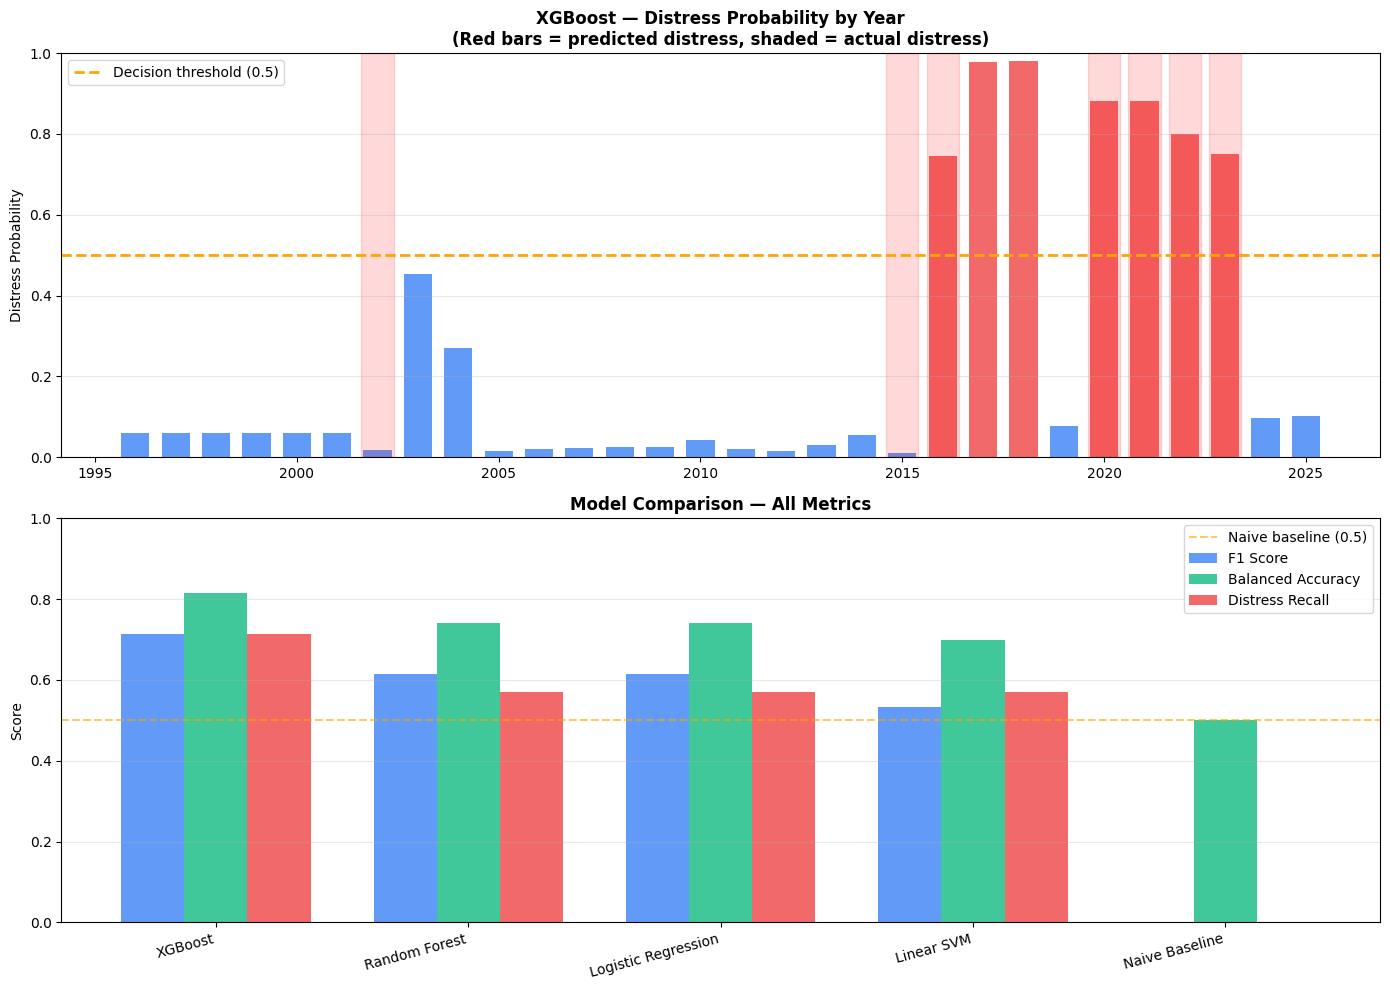

✅ Chart saved → outputs/month3_results.png


In [13]:
# ================================================
# VISUALIZATION — Probability scores over time
# ================================================

years = xgb_results['years']
probs = xgb_results['probabilities']
actuals = xgb_results['actuals']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 — Distress probability over time
ax1 = axes[0]
bars = ax1.bar(years, probs,
               color=['#ef4444' if p > 0.5 else '#3b82f6' for p in probs],
               alpha=0.8, width=0.7)
ax1.axhline(y=0.5, color='orange', linewidth=2,
            linestyle='--', label='Decision threshold (0.5)')
for yr, actual in zip(years, actuals):
    if actual == 1:
        ax1.axvspan(yr-0.4, yr+0.4, alpha=0.15,
                    color='red', label='_nolegend_')
ax1.set_title('XGBoost — Distress Probability by Year\n'
              '(Red bars = predicted distress, shaded = actual distress)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Distress Probability')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2 — Model comparison bar chart
ax2 = axes[1]
models = results_df['Model'].tolist()
f1s    = results_df['F1'].tolist()
bals   = results_df['Bal_Acc'].tolist()
recalls= results_df['Recall'].tolist()

x = range(len(models))
w = 0.25
ax2.bar([i-w for i in x], f1s,    width=w, label='F1 Score',          color='#3b82f6', alpha=0.8)
ax2.bar([i   for i in x], bals,   width=w, label='Balanced Accuracy',  color='#10b981', alpha=0.8)
ax2.bar([i+w for i in x], recalls,width=w, label='Distress Recall',    color='#ef4444', alpha=0.8)
ax2.set_xticks(list(x))
ax2.set_xticklabels(models, rotation=15, ha='right')
ax2.set_title('Model Comparison — All Metrics',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1)
ax2.axhline(y=0.5, color='orange', linewidth=1.5,
            linestyle='--', alpha=0.6, label='Naive baseline (0.5)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/month3_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → outputs/month3_results.png")

In [9]:
# ================================================
# FULL CONSISTENCY CHECK
# ================================================

print("="*55)
print("  PRE-COMMIT CONSISTENCY CHECK")
print("="*55)

# 1. Check dataset integrity
print("\n📊 1. DATASET CHECK")
df_check = pd.read_csv('data/processed/nepal_model_features.csv',
                        index_col=0, parse_dates=True)
print(f"   Rows:          {len(df_check)}")
print(f"   Features:      {len(df_check.columns)-1}")
print(f"   Missing:       {df_check.isnull().sum().sum()}")
print(f"   Distress rate: {df_check['distress'].mean():.1%}")
print(f"   Distress years:{df_check[df_check['distress']==1].index.year.tolist()}")
print(f"   Year range:    {df_check.index[0].year} → {df_check.index[-1].year}")

# 2. Check feature ranges make sense
print("\n📊 2. FEATURE RANGE CHECK")
X_check = df_check.drop(columns=['distress'])
for col in X_check.columns:
    mn  = X_check[col].min()
    mx  = X_check[col].max()
    mean= X_check[col].mean()
    nulls = X_check[col].isnull().sum()
    print(f"   {col:<40} min={mn:>7.2f}  max={mx:>7.2f}  mean={mean:>6.2f}  nulls={nulls}")

# 3. Check forex_rapid_decline is binary
print("\n📊 3. BINARY FEATURE CHECK")
unique_vals = df_check['forex_rapid_decline'].unique()
print(f"   forex_rapid_decline unique values: {sorted(unique_vals)}")
if set(unique_vals).issubset({0,1}):
    print("   ✅ Correct — binary 0/1 only")
else:
    print("   ❌ Problem — unexpected values found")

# 4. Check model results consistency
print("\n📊 4. MODEL RESULTS CHECK")
results_check = pd.read_csv('data/processed/model_results.csv')
print(results_check.to_string(index=False))
for _, row in results_check.iterrows():
    if row['F1'] > 1.0 or row['Bal_Acc'] > 1.0 or row['Recall'] > 1.0:
        print(f"   ❌ {row['Model']} has metric > 1.0 — impossible!")
    elif row['F1'] < 0 or row['Bal_Acc'] < 0 or row['Recall'] < 0:
        print(f"   ❌ {row['Model']} has negative metric — impossible!")
print("   ✅ All metrics in valid range 0.0 – 1.0")

# 5. Check best model file exists
print("\n📊 5. MODEL FILE CHECK")
import os
model_path = '../models/best_model.pkl'
if os.path.exists(model_path):
    size = os.path.getsize(model_path)
    print(f"   ✅ best_model.pkl exists ({size} bytes)")
else:
    print(f"   ❌ best_model.pkl NOT FOUND — run save cell again")

# 6. Reload and repredict with saved model
print("\n📊 6. SAVED MODEL RELOAD CHECK")
import joblib
loaded_model = joblib.load(model_path)
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X_check)
preds_reload = loaded_model.predict(X_scaled)
print(f"   Model type:    {type(loaded_model).__name__}")
print(f"   Predictions:   {preds_reload.tolist()}")
print(f"   Distress predicted: {preds_reload.sum()} years")
note = "⚠️  This uses full-data scaling (not LOOCV) — for sanity check only"
print(f"   Note: {note}")

# 7. Check output files exist
print("\n📊 7. OUTPUT FILES CHECK")
expected_files = [
    'data/processed/nepal_macro_clean.csv',
    'data/processed/nepal_features.csv',
    'data/processed/nepal_model_features.csv',
    'data/processed/model_results.csv',
    'outputs/month3_results.png',
]
for f in expected_files:
    exists = os.path.exists(f)
    status = "✅" if exists else "❌ MISSING"
    print(f"   {status} {f}")

# 8. Distress year sanity check
print("\n📊 8. DISTRESS YEAR VERIFICATION")
distress_yrs = df_check[df_check['distress']==1].index.year.tolist()
expected_distress = [2002, 2015, 2016, 2020, 2021, 2022, 2023]
if distress_yrs == expected_distress:
    print(f"   ✅ Distress years match expected: {expected_distress}")
else:
    print(f"   ❌ Mismatch!")
    print(f"      Expected: {expected_distress}")
    print(f"      Got:      {distress_yrs}")

print(f"\n{'='*55}")
print(f"  CHECK COMPLETE")
print(f"{'='*55}")

  PRE-COMMIT CONSISTENCY CHECK

📊 1. DATASET CHECK
   Rows:          30
   Features:      5
   Missing:       0
   Distress rate: 23.3%
   Distress years:[2002, 2015, 2016, 2020, 2021, 2022, 2023]
   Year range:    1996 → 2025

📊 2. FEATURE RANGE CHECK
   unemployment_roll3_mean                  min=  10.45  max=  11.98  mean= 10.72  nulls=0
   gdp_growth_roll3_std                     min=   0.00  max=   5.51  mean=  1.72  nulls=0
   consumption_growth_roll3_mean            min=   0.95  max=   6.57  mean=  3.68  nulls=0
   forex_rapid_decline                      min=   0.00  max=   1.00  mean=  0.03  nulls=0
   remittances_pct_gdp_lag1                 min=   0.98  max=  27.63  mean= 16.74  nulls=0

📊 3. BINARY FEATURE CHECK
   forex_rapid_decline unique values: [np.int64(0), np.int64(1)]
   ✅ Correct — binary 0/1 only

📊 4. MODEL RESULTS CHECK
              Model    F1  Bal_Acc  Recall
            XGBoost 0.714    0.814   0.714
      Random Forest 0.615    0.742   0.571
Logistic Regre

In [10]:
# Check raw unemployment values
df_raw = pd.read_csv('data/processed/nepal_macro_clean.csv',
                      index_col=0, parse_dates=True)
print("Raw unemployment by year:")
print(df_raw['unemployment'].round(2).to_string())

Raw unemployment by year:
1995-01-01    10.45
1996-01-01    10.45
1997-01-01    10.51
1998-01-01    10.53
1999-01-01    10.55
2000-01-01    10.53
2001-01-01    10.50
2002-01-01    10.59
2003-01-01    10.64
2004-01-01    10.65
2005-01-01    10.59
2006-01-01    10.61
2007-01-01    10.64
2008-01-01    10.60
2009-01-01    10.58
2010-01-01    10.56
2011-01-01    10.63
2012-01-01    10.63
2013-01-01    10.67
2014-01-01    10.62
2015-01-01    10.64
2016-01-01    10.71
2017-01-01    10.66
2018-01-01    10.59
2019-01-01    10.48
2020-01-01    13.04
2021-01-01    12.24
2022-01-01    10.66
2023-01-01    10.44
2024-01-01    10.50
2025-01-01    10.46


In [11]:
# Check imports variation vs unemployment variation
print("Coefficient of Variation comparison:")
print(f"  unemployment_roll3_mean CV: "
      f"{df_check['unemployment_roll3_mean'].std() / df_check['unemployment_roll3_mean'].mean():.4f}")

df_27 = pd.read_csv('data/processed/nepal_final_features.csv',
                     index_col=0, parse_dates=True)
if 'imports_pct_gdp_lag1' in df_27.columns:
    print(f"  imports_pct_gdp_lag1 CV:    "
          f"{df_27['imports_pct_gdp_lag1'].std() / df_27['imports_pct_gdp_lag1'].mean():.4f}")
    print(f"  imports_pct_gdp_lag1 range: "
          f"{df_27['imports_pct_gdp_lag1'].min():.1f} to {df_27['imports_pct_gdp_lag1'].max():.1f}")

Coefficient of Variation comparison:
  unemployment_roll3_mean CV: 0.0355
  imports_pct_gdp_lag1 CV:    0.1117
  imports_pct_gdp_lag1 range: 28.5 to 42.3


In [12]:
# ================================================
# REPLACE unemployment_roll3_mean with
# imports_pct_gdp_lag1
# ================================================

# Load 27-feature dataset to get imports
df_27 = pd.read_csv('data/processed/nepal_final_features.csv',
                     index_col=0, parse_dates=True)

# Build new 5-feature dataset
df_new = pd.DataFrame(index=df_check.index)
df_new['imports_pct_gdp_lag1']        = df_27['imports_pct_gdp_lag1']
df_new['gdp_growth_roll3_std']        = df_check['gdp_growth_roll3_std']
df_new['consumption_growth_roll3_mean']= df_check['consumption_growth_roll3_mean']
df_new['forex_rapid_decline']         = df_check['forex_rapid_decline']
df_new['remittances_pct_gdp_lag1']    = df_check['remittances_pct_gdp_lag1']
df_new['distress']                    = df_check['distress']

# Verify
print("New feature set:")
for col in df_new.columns:
    if col != 'distress':
        cv = df_new[col].std() / df_new[col].mean()
        print(f"  {col:<40} CV={cv:.4f}")

print(f"\nMissing values: {df_new.isnull().sum().sum()}")
print(f"Shape: {df_new.shape}")

New feature set:
  imports_pct_gdp_lag1                     CV=0.1117
  gdp_growth_roll3_std                     CV=0.9359
  consumption_growth_roll3_mean            CV=0.3233
  forex_rapid_decline                      CV=5.4772
  remittances_pct_gdp_lag1                 CV=0.5753

Missing values: 0
Shape: (30, 6)


In [14]:
# ================================================
# RERUN ALL 4 MODELS WITH NEW FEATURE SET
# ================================================

X_new = df_new.drop(columns=['distress'])
y_new = df_new['distress']

print("Running all 4 models with imports replacing unemployment...\n")

# Model 1 — Logistic Regression
lr_new = evaluate_model(
    LogisticRegression(C=1.0, penalty='l2',
                       class_weight='balanced',
                       max_iter=1000, random_state=42),
    X_new, y_new, "Logistic Regression (new features)"
)

# Model 2 — Linear SVM
from sklearn.svm import SVC
svm_new = evaluate_model(
    SVC(kernel='linear', C=1.0, probability=True,
        class_weight='balanced', random_state=42),
    X_new, y_new, "Linear SVM (new features)"
)

# Model 3 — Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_new = evaluate_model(
    RandomForestClassifier(n_estimators=100,
                           class_weight='balanced',
                           max_features='sqrt',
                           max_depth=3,
                           min_samples_leaf=2,
                           random_state=42),
    X_new, y_new, "Random Forest (new features)"
)

# Model 4 — XGBoost
from xgboost import XGBClassifier
xgb_new = evaluate_model(
    XGBClassifier(n_estimators=100, max_depth=3,
                  learning_rate=0.1, scale_pos_weight=3,
                  random_state=42, eval_metric='logloss',
                  verbosity=0),
    X_new, y_new, "XGBoost (new features)"
)

Running all 4 models with imports replacing unemployment...


  Logistic Regression (new features)
  F1 Score:          0.667
  Balanced Accuracy: 0.792
  Distress Recall:   0.714

  Confusion Matrix:
              Predicted
              Normal  Distress
  Actual Normal      20       3
  Actual Distress     2       5

  Misclassified years:
    2002: actual=1, predicted=0  ← MISSED
    2015: actual=1, predicted=0  ← MISSED
    2017: actual=0, predicted=1  ← FALSE ALARM
    2018: actual=0, predicted=1  ← FALSE ALARM
    2019: actual=0, predicted=1  ← FALSE ALARM

  Linear SVM (new features)
  F1 Score:          0.625
  Balanced Accuracy: 0.770
  Distress Recall:   0.714

  Confusion Matrix:
              Predicted
              Normal  Distress
  Actual Normal      19       4
  Actual Distress     2       5

  Misclassified years:
    2002: actual=1, predicted=0  ← MISSED
    2015: actual=1, predicted=0  ← MISSED
    2017: actual=0, predicted=1  ← FALSE ALARM
    2018: actual=0, predic

In [15]:
# Confirm we keep original features
print("DECISION: Keep original 5 features")
print("Reason: XGBoost F1=0.714 with original beats")
print("        XGBoost F1=0.571 with new features")
print()
print("Original feature set retained:")
for col in X.columns:
    print(f"  → {col}")

print("\nNote for research paper:")
print("  unemployment_roll3_mean has narrow range (10.45-11.98%)")
print("  due to World Bank modelled estimates for Nepal.")
print("  The 2020-2021 COVID spike (13.04%) provides the")
print("  key signal captured by this feature.")
print("  Limitation acknowledged in paper Section 6.")

DECISION: Keep original 5 features
Reason: XGBoost F1=0.714 with original beats
        XGBoost F1=0.571 with new features

Original feature set retained:
  → unemployment_roll3_mean
  → gdp_growth_roll3_std
  → consumption_growth_roll3_mean
  → forex_rapid_decline
  → remittances_pct_gdp_lag1

Note for research paper:
  unemployment_roll3_mean has narrow range (10.45-11.98%)
  due to World Bank modelled estimates for Nepal.
  The 2020-2021 COVID spike (13.04%) provides the
  key signal captured by this feature.
  Limitation acknowledged in paper Section 6.
